In [28]:
import geopandas as gpd
import shapely.geometry as geom
import pandas as pd
import numpy as np

# Geospatial polygons to a csv data

Downloaded the geospatial polygons from the Indian government boundary data.
https://data.humdata.org/dataset/geoboundaries-admin-boundaries-for-india

Will transform that into a csv file with  10x10 granularity for each latitude-longitude box.

In [29]:
series = gpd.read_file("../data/india-boundaries.geojson")["geometry"]

lat = np.linspace(5, 38, 331)
lon = np.linspace(66, 98, 321)

lad = []
lod = []
cod = []

for l in lat:
    for lo in lon:
        point = geom.Point(lo, l)
        lad.append(l)
        lod.append(lo)
        cod.append(series.contains(point).any())

dataframe = pd.DataFrame({'lat': lad, 'lon': lod, 'contains': cod})

In [30]:
dataframe

,lat,lon,contains
0,5.0,66.0,False
1,5.0,66.1,False
2,5.0,66.2,False
3,5.0,66.3,False
4,5.0,66.4,False
...,...,...,...
106246,38.0,97.6,False
106247,38.0,97.7,False
106248,38.0,97.8,False
106249,38.0,97.9,False


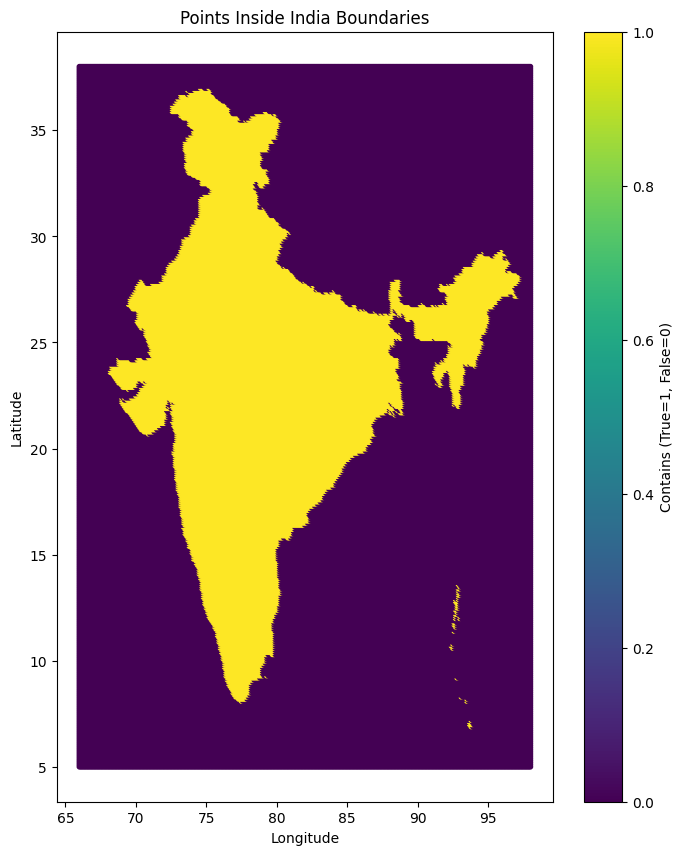

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
scatter = plt.scatter(dataframe['lon'], dataframe['lat'], c=dataframe['contains'], cmap='viridis', s=10)
plt.colorbar(scatter, label='Contains (True=1, False=0)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Points Inside India Boundaries')
plt.show()

In [32]:
dataframe.to_csv("../data/india-boundaries.csv", header=True, index=False, mode='w')